In [1]:
import shap, xgboost
print("shap:", shap.__version__)
print("xgboost:", xgboost.__version__)

c:\Users\Visveswaran\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap: 0.49.1
xgboost: 1.7.6


In [2]:
import sqlite3
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

conn = sqlite3.connect("../retailiq.db")
df = pd.read_sql("SELECT * FROM customer_features", conn)
conn.close()

feature_cols = [
    "frequency", "repeat_order_count", "avg_days_between_orders",
    "avg_review_score", "review_count", "avg_delivery_days", "avg_delay_days",
    "treatment_voucher"
]
target = "churned"

model_df = df[feature_cols + [target]].dropna()
X = model_df[feature_cols]

clf = joblib.load("../models_churn.pkl")

X_sample = X.sample(min(2000, len(X)), random_state=42)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_sample)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (2000, 8)


In [3]:
import xgboost
print(xgboost.__version__)

1.7.6


In [4]:
import sys
print(sys.executable)

c:\Users\Visveswaran\AppData\Local\Programs\Python\Python310\python.exe


In [5]:
import sys
!{sys.executable} -m pip install "xgboost==1.7.6"


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import xgboost
print(xgboost.__version__)

1.7.6


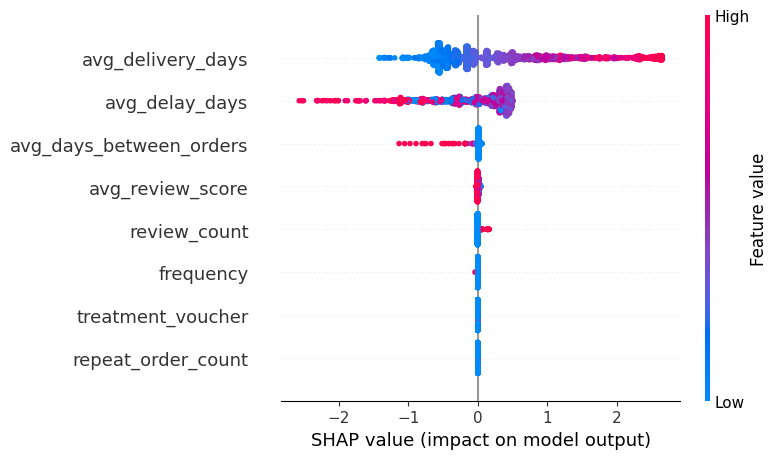

In [7]:
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig("../docs/shap_churn_summary.png", dpi=150, bbox_inches="tight")
plt.show()

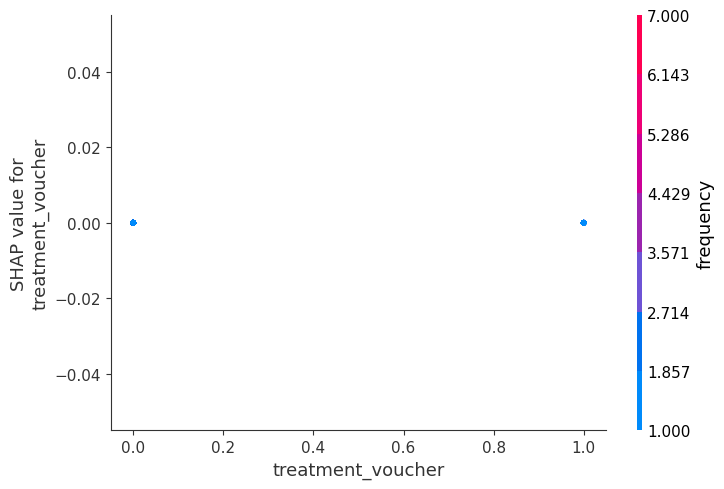

In [8]:
shap.dependence_plot("treatment_voucher", shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig("../docs/shap_churn_voucher_dependence.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.Series(mean_abs_shap, index=X_sample.columns).sort_values(ascending=False)
print(feature_importance.head(3))

avg_delivery_days          0.704464
avg_delay_days             0.424170
avg_days_between_orders    0.020404
dtype: float32


In [12]:
import numpy as np